In [24]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import StepLR
import sys
sys.path.append('../..')
from src import train, utils
import src.data.aquarium_domain as aq
import src.data.parametric_domain as pd
import src.models.mlp_model as mm
import src.models.multihead as mh

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
L_BOUNDS_PARAM = 8*[-3]
U_BOUNDS_PARAM = 8*[3]
L_BOUNDS_DOMAIN = [-50, -50, 0]
U_BOUNDS_DOMAIN = [50, 50, 400 * 24 * 3600]

k_0 = 6.0e-19
E = 6e10
NU = 0.2
ALPHA = 0.2
C_0 = 7.712e-12
R=2
P_OUTER=-3e6
mu_f=1.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
core_domain_ctx = aq.AquariumContext(
    dim=3,
    N_int=20_000,
    N_sides=[(0, 0), (0, 0), (0, 0)],
    device=device,
    time_dependant=False,
    ball_centre=torch.tensor([0,0], device=device),
    ball_r=R,
    ball_dim=2,
    l_bounds=L_BOUNDS_DOMAIN,
    u_bounds=U_BOUNDS_DOMAIN
    )

core_domain = aq.AquariumDomain(core_domain_ctx)
domain = pd.ParametricDomain(core_domain, 8, L_BOUNDS_PARAM, U_BOUNDS_PARAM)


In [27]:
def p_tun(t):
    return P_OUTER * torch.clamp(1.0 - (t / (17.0 * 24.0 * 3600.0)), 0.0)

def p_lift(x):
    p_outer_tensor = P_OUTER * torch.ones_like(x[:, 2:3])
    rho = (torch.sqrt(x[:, 0:1]**2 + x[:, 1:2]**2 + 1e-12) - R) / (50.0 - R)
    return (1.0 - rho) * p_tun(x[:, 2:3]) + rho * p_outer_tensor

def u_lift(x):
    zeros = torch.zeros_like(x[:, 0:1])
    return torch.column_stack([zeros, zeros])

def D_u_zero(x):
    D_ux = 1 - (x[:, 0:1] / 50)**2
    D_uy = 1 - (x[:, 1:2] / 50)**2
    return torch.column_stack([D_ux, D_uy])

def D_p_zero(x):
    D_inner = (torch.sqrt(x[:, 0:1]**2 + x[:, 1:2]**2 + 1e-12) - R) / (50.0 - R)
    D_outer = R - (x[:, 0:1] / 50.0)**2 - (x[:, 1:2] / 50.0)**2
    return D_inner * D_outer

In [ ]:
u_scale = torch.tensor([1e-3, 1e-3], device=device)
p_scale = torch.tensor([3e6], device=device)

mlp_trunk_ctx = mm.ModelContext(
    input_dim=11,
    output_dim=64,
    layer = [64, 64],
    u_bounds=U_BOUNDS_DOMAIN + U_BOUNDS_PARAM,
    l_bounds=L_BOUNDS_DOMAIN + L_BOUNDS_PARAM,    
)

mlp_u_ctx = mm.ModelContext(
    input_dim=64,
    output_dim=2,
    layer=[32],
    normalize_input=False,
    hard_enforce=True,
    constraint_functions=[u_lift, D_u_zero],
    output_scale_factor=u_scale
)

mlp_p_ctx = mm.ModelContext(
    input_dim=64,
    output_dim=1,
    layer=[32],
    normalize_input=False,
    hard_enforce=True,
    constraint_functions=[p_lift, D_p_zero],
    output_scale_factor=p_scale
)

model_trunk = mm.MLPModel(mlp_trunk_ctx).to(device)
model_u = mm.MLPModel(mlp_u_ctx).to(device)
model_p = mm.MLPModel(mlp_p_ctx).to(device)

mh_model = mh.MultiheadModel(model_trunk, model_u, model_p)

mh_optim = torch.optim.Adam(mh_model.parameters(), lr=0.001)

## Pretraining

In [ ]:
import numpy as np

data = np.load('tsx_training_samples_small.npz', allow_pickle=True)

samples      = data['data']            # main data array
xi           = data['xi']              # parameter samples
query_pts_xy = data['query_points_xy'] # spatial query points
store_days   = data['store_days']      # time snapshots
columns      = data['columns']         # column names

print("data:            ", samples.shape)
print("xi:              ", xi.shape)
print("query_points_xy: ", query_pts_xy.shape)
print("store_days:      ", store_days.shape)
print("columns:         ", columns[12:])

print(samples.shape)

# Train on ALL realizations so the network sees xi variation
sample_tesnor = torch.from_numpy(samples[:, 1:12].astype(float)).to(device).float()
sample_tesnor[:, 2:3] *= 24 * 3600 # correct units
sample_out_tensor = torch.from_numpy(samples[:, 12:].astype(float)).to(device).float()

train_mask = (samples[:, 0] <= 180)
test_mask = (samples[:, 0] > 180)

input_training_points = sample_tesnor[train_mask]
input_testing_points = sample_tesnor[~train_mask]

output_training_points = sample_out_tensor[train_mask]
output_testing_points = sample_out_tensor[~train_mask]

print("input tensor:  ", sample_tesnor.shape)
print("output tensor: ", sample_out_tensor.shape)

data:             (320000, 15)
xi:               (200, 8)
query_points_xy:  (400, 2)
store_days:       (4,)
columns:          ['u_x' 'u_y' 'p']
(320000, 15)
input tensor:   torch.Size([320000, 11])
output tensor:  torch.Size([320000, 3])


In [ ]:
u_x_s = 1e-3
u_y_s = 1e-3
p_s = 3e6

def pretrain_loss(model, domain):    
    out = model(input_training_points)

    loss_data_u_x = torch.mean(((out[:, 0] - output_training_points[:, 0]) / u_x_s)**2)
    loss_data_u_y = torch.mean(((out[:, 1] - output_training_points[:, 1]) / u_y_s)**2)
    loss_data_p = torch.mean(((out[:, 2] - output_training_points[:, 2]) / p_s)**2)

    return [loss_data_u_x + loss_data_u_y + loss_data_p]

In [ ]:
context = train.TrainingContext(
    model=mh_model,
    domain=domain,
    optimizer=mh_optim,
    loss_fn=pretrain_loss,
    epochs=5_000,
    monitor_lr=True,
    monitor_gradient=True,
    loss_weights=[1.0]
)

total_loss_values, component_loss_values, grad_norm_per_loss = train.simple_train(context)

Epoch: 1. Loss: 0.029387954622507095. Total grad: 0.45677704705077543 0-th grad: 0.45677704705077543 0-th weight: 1.0 Current learing rate: 0.001
 Epoch: 100. Loss: 0.006114039570093155. Total grad: 0.0010706633121506748 0-th grad: 0.0010706633121506748 0-th weight: 1.0 Current learing rate: 0.001
 Epoch: 200. Loss: 0.006077567581087351. Total grad: 0.007019123483089503 0-th grad: 0.007019123483089503 0-th weight: 1.0 Current learing rate: 0.001
 

KeyboardInterrupt: 

## Validation before residual training

In [ ]:
test_inp = input_testing_points.requires_grad_(True)
test_pred = mh_model(test_inp)
test_pred_ux = test_pred[:, 0:1]
test_pred_uy = test_pred[:, 1:2]
test_pred_p = test_pred[:, 2:3]

l2_relative_p = torch.norm(test_pred_p - output_testing_points[:, 2:3], p=2) / torch.norm(output_testing_points[:, 2:3], p=2)
l2_relative_ux = torch.norm(test_pred_ux - output_testing_points[:, 0:1], p=2) / torch.norm(output_testing_points[:, 0:1], p=2)
l2_relative_uy = torch.norm(test_pred_uy - output_testing_points[:, 1:2], p=2) / torch.norm(output_testing_points[:, 1:2], p=2)

print(f"Relative pressure L2 error: {l2_relative_p}")
print(f"Relative x-velocity L2 error: {l2_relative_ux}")
print(f"Relative y-velocity L2 error: {l2_relative_uy}")

Relative pressure L2 error: 0.0015888761263340712
Relative x-velocity L2 error: 0.055769264698028564
Relative y-velocity L2 error: 0.17268706858158112


## Residual training

In [ ]:
from math import pi, log

gamma = torch.tensor(
    [1.00, 0.70, 0.70, 0.50, 0.35, 0.35, 0.25, 0.25],
    device=device
).view(1, 8)

def permeability_k(z, k0=6.0e-19, amp=0.35):
    x = z[:, 0:1]
    y = z[:, 1:2]
    xi = z[:, 3:11]
    X = (x + 50.0) / 100.0
    Y = (y + 50.0) / 100.0

    phi = torch.cat([
        torch.sin(pi*X) * torch.sin(pi*Y),
        torch.cos(2*pi*X) * torch.sin(pi*Y),
        torch.sin(pi*X) * torch.cos(2*pi*Y),
        torch.cos(2*pi*X) * torch.cos(2*pi*Y),
        torch.sin(3*pi*X) * torch.sin(pi*Y),
        torch.sin(pi*X) * torch.sin(3*pi*Y),
        torch.cos(3*pi*X) * torch.sin(2*pi*Y),
        torch.sin(2*pi*X) * torch.cos(3*pi*Y),
    ], dim=1)

    logk = log(k0) + amp * (gamma * phi * xi).sum(dim=1, keepdim=True)
    return torch.exp(logk)

In [ ]:
def res(x, u, v, p):
    dp = grad(p, x, torch.ones_like(p), create_graph=True)[0]
    du = grad(u, x, torch.ones_like(u), create_graph=True)[0]
    dv = grad(v, x, torch.ones_like(v), create_graph=True)[0]

    u_x, u_y = du[:, 0:1], du[:, 1:2]
    v_x, v_y = dv[:, 0:1], dv[:, 1:2]
    p_x, p_y, p_t = dp[:, 0:1], dp[:, 1:2], dp[:, 2:3]

    div_u = u_x + v_y
    eps_xx = u_x
    eps_yy = v_y
    eps_xy = 0.5 * (u_y + v_x)

    mu = E / (2.0 * (1.0 + NU))
    lam = E * NU / ((1.0 + NU) * (1.0 - 2.0*NU))

    sig_xx = 2.0 * mu * eps_xx + lam * div_u - ALPHA * p
    sig_yy = 2.0 * mu * eps_yy + lam * div_u - ALPHA * p
    sig_xy = 2.0 * mu * eps_xy

    dsig_xx = grad(sig_xx, x, torch.ones_like(sig_xx), create_graph=True)[0]
    dsig_yy = grad(sig_yy, x, torch.ones_like(sig_yy), create_graph=True)[0]
    dsig_xy = grad(sig_xy, x, torch.ones_like(sig_xy), create_graph=True)[0]

    res_x = - (dsig_xx[:, 0:1] + dsig_xy[:, 1:2])
    res_y = - (dsig_xy[:, 0:1] + dsig_yy[:, 1:2])

    p_xx = grad(p_x, x, torch.ones_like(p_x), create_graph=True)[0][:, 0:1]
    p_yy = grad(p_y, x, torch.ones_like(p_y), create_graph=True)[0][:, 1:2]

    K = permeability_k(x) / mu_f
    dK = grad(K, x, torch.ones_like(K), create_graph=True)[0]
    K_x, K_y = dK[:, 0:1], dK[:, 1:2]

    div_K_dp = K_x * p_x + K * p_xx + K_y * p_y + K * p_yy
    
    div_u_t = grad(div_u, x, torch.ones_like(div_u), create_graph=True)[0][:, 2:3]
    
    res_p = C_0 * p_t + ALPHA * div_u_t - div_K_dp

    return res_x, res_y, res_p
    

In [ ]:
res_x_s = 1e6
res_y_s = 1e6
res_p_s = 1e-9

def res_loss(model: torch.nn.Module, domain: aq.AquariumDomain):
    x = domain.interior.requires_grad_(True)
    uvp = model(x)
    u, v, p = uvp[:, 0:1], uvp[:, 1:2], uvp[:, 2:3]
    res_x, res_y, res_p = res(x, u, v, p)

    loss_data = pretrain_loss(model, domain)[0]
    loss_momentum = torch.mean((res_x / res_x_s)**2) + torch.mean((res_y / res_y_s)**2)
    loss_mass = torch.mean((res_p / res_p_s)**2)

    return [loss_data, loss_momentum, loss_mass]

In [ ]:
context.loss_fn = res_loss
context.epochs = 25_000
context.loss_weights = [0.05, 1.0, 1.0]
context.optimizer = torch.optim.Adam(mh_model.parameters(), lr=0.0001)

total_loss_values, component_loss_values, grad_norm_per_loss = train.simple_train(context)

Epoch: 1. Loss: 0.6442484855651855. Total grad: 8.354453203234518 0-th grad: 0.0013098171419572513 0-th weight: 0.05 1-th grad: 8.35443062889823 1-th weight: 1.0 2-th grad: 9.02981040339761e-05 2-th weight: 1.0 Current learing rate: 0.0001
 Epoch: 100. Loss: 0.0003155649174004793. Total grad: 0.0039587011891356015 0-th grad: 0.002487781501521362 0-th weight: 1.4997500221322 1-th grad: 5.841724575442091 1-th weight: 0.0004999557356002763 2-th grad: 9.72339366438834e-05 2-th weight: 1.4997500221322 Current learing rate: 0.0001
 Epoch: 200. Loss: 0.00028969362028874457. Total grad: 0.001836766491311431 0-th grad: 0.0018181252624337786 0-th weight: 1.499750022575855 1-th grad: 5.063618174754947 1-th weight: 0.0004999548482898852 2-th grad: 0.00010947427218915421 2-th weight: 1.499750022575855 Current learing rate: 0.0001
 Epoch: 300. Loss: 0.0002926673332694918. Total grad: 0.0025579497634506004 0-th grad: 0.0007146314955806147 0-th weight: 1.4997500254117888 1-th grad: 5.473773724461716 1

## Visualization

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/parametric/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)
/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/parametric/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


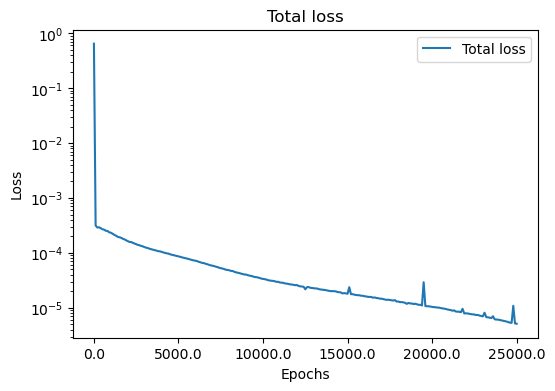

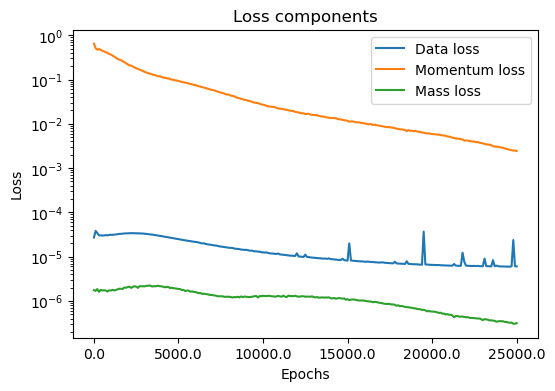

In [ ]:
import os
os.makedirs('biot_images', exist_ok=True)

# Total loss
plot_context = utils.PlotContext(
    u_bounds=U_BOUNDS_DOMAIN,
    l_bounds=L_BOUNDS_DOMAIN,
    figsize=(8,6),
    patches=None,
    device=device,
    vmin=0,
    vmax=2,
    N=100,
    titles=['Total loss'],
    function_names=['u'],
    x_label='Epochs',
    y_label='Loss',
    save_img=True,
    save_path='./biot_images/total_loss.png'
)

plot_context.titles = ["Total loss"]
utils.plot_loss_values({'Total loss': total_loss_values}, plot_context)


plot_context.titles = ['Loss components']
plot_context.save_path = './biot_images/component_loss.png'
utils.plot_loss_values({'Data loss': component_loss_values[0],
                        'Momentum loss': component_loss_values[1],
                        'Mass loss': component_loss_values[2]}, plot_context)



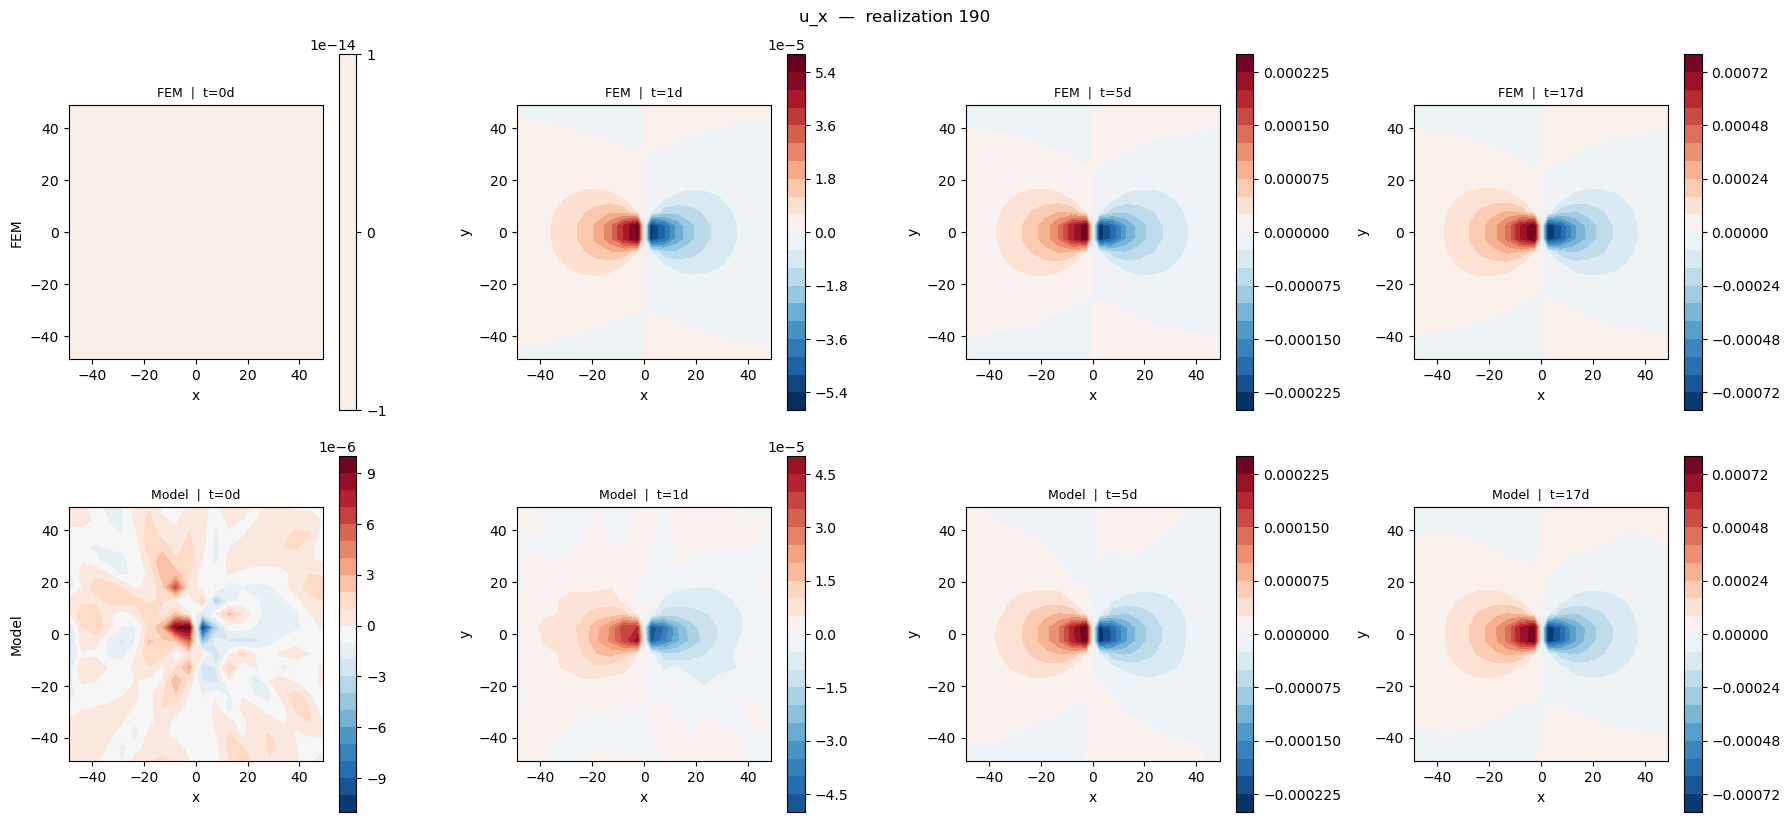

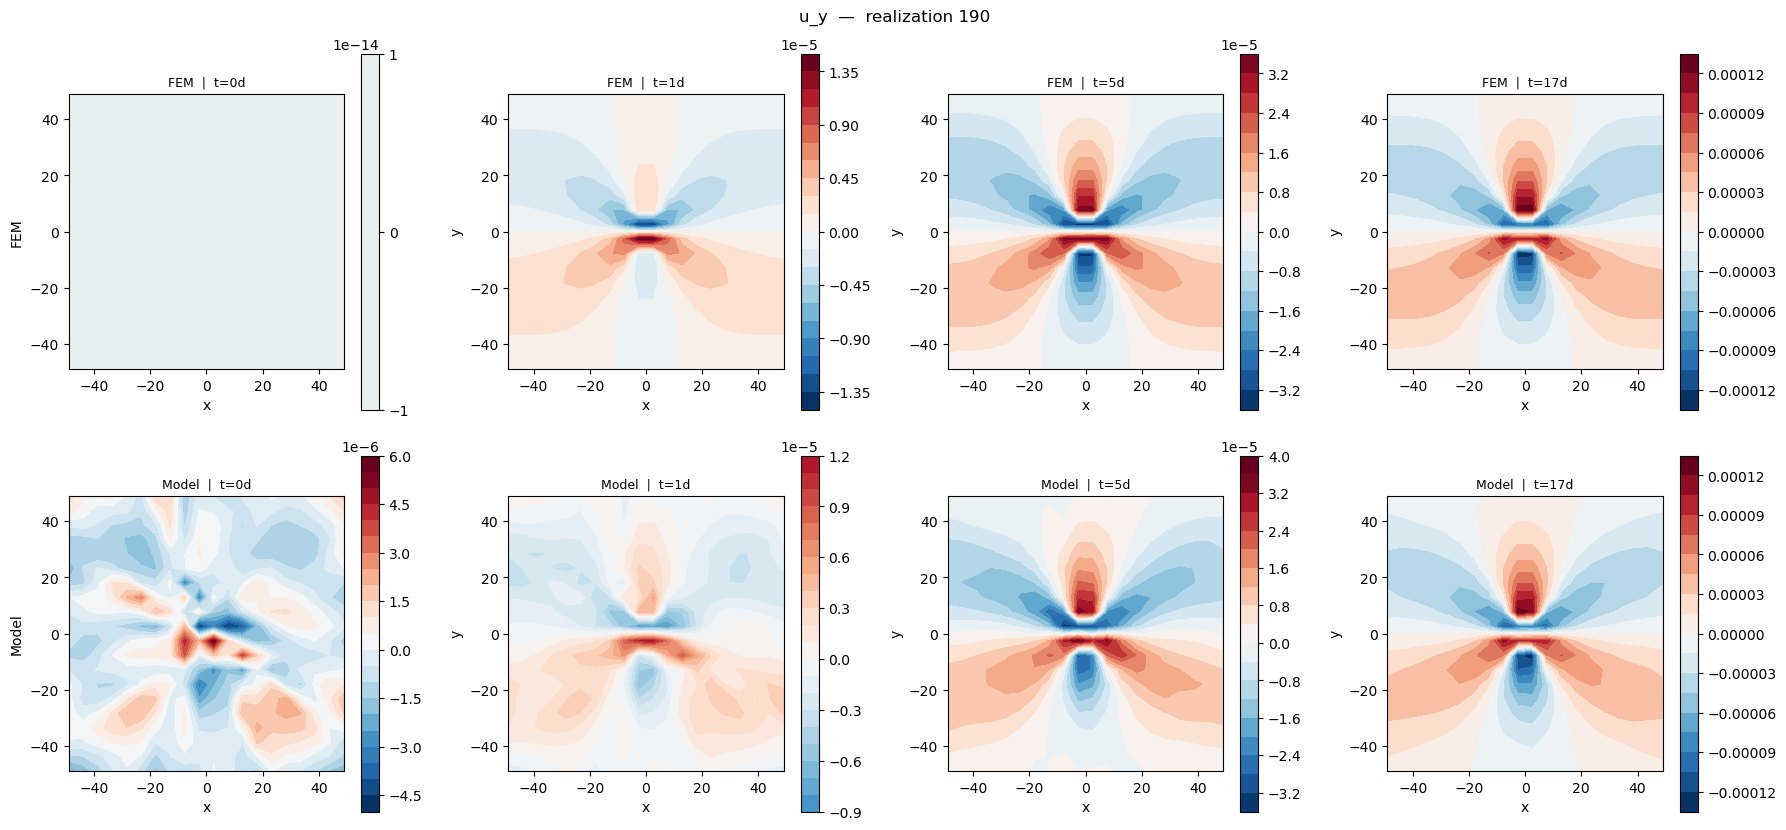

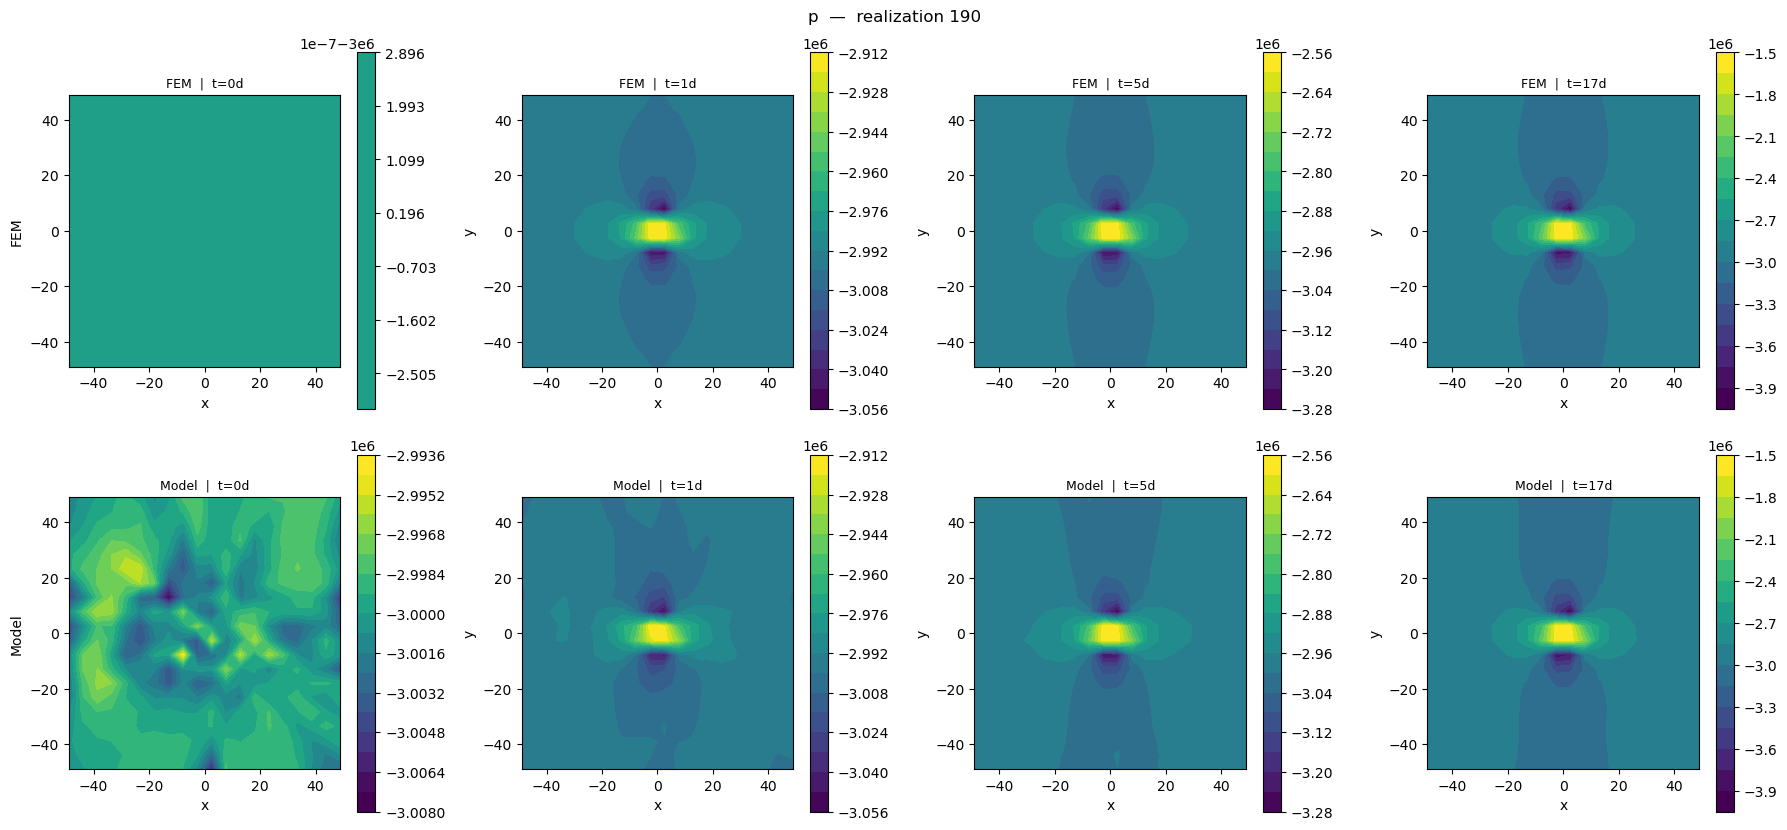

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

REAL = 190

col    = {name: i for i, name in enumerate(columns)}
N_side = int(np.sqrt(query_pts_xy.shape[0]))
n_days = len(store_days)

real_samples = samples[samples[:, col['realization']] == REAL]

field_info = [
    ('u_x', 'u_x', 0, 'RdBu_r'),
    ('u_y', 'u_y', 1, 'RdBu_r'),
    ('p',   'p',   2, 'viridis'),
]

for field_label, col_name, out_idx, cmap in field_info:
    fig, axes = plt.subplots(
        2, n_days,
        figsize=(4.5 * n_days, 8.5),
        squeeze=False,
    )

    for t_idx, day in enumerate(store_days):
        chunk = real_samples[real_samples[:, col['t_days']] == day]

        xx = chunk[:, col['x']].reshape(N_side, N_side)
        yy = chunk[:, col['y']].reshape(N_side, N_side)
        gt = chunk[:, col[col_name]].reshape(N_side, N_side)

        x_in = torch.from_numpy(chunk[:, 1:12].astype(float)).float().to(device)
        x_in[:, 2:3] *= 24 * 3600
        with torch.no_grad():
            pred_np = mh_model(x_in).cpu().numpy()
        pred_f = pred_np[:, out_idx].reshape(N_side, N_side)

        vmin = min(gt.min(), pred_f.min())
        vmax = max(gt.max(), pred_f.max())
        levels = 20

        # --- FEM (top row) ---
        ax = axes[0, t_idx]
        im = ax.contourf(xx, yy, gt, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax)
        ax.set_title(f'FEM  |  t={day:.0f}d', fontsize=9)
        ax.set_aspect('equal')
        ax.set_xlabel('x')
        ax.set_ylabel('y')

        # --- Model (bottom row) ---
        ax = axes[1, t_idx]
        im = ax.contourf(xx, yy, pred_f, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax)
        ax.set_title(f'Model  |  t={day:.0f}d', fontsize=9)
        ax.set_aspect('equal')
        ax.set_xlabel('x')
        ax.set_ylabel('y')

    axes[0, 0].set_ylabel('FEM')
    axes[1, 0].set_ylabel('Model')

    fig.suptitle(f'{field_label}  —  realization {int(REAL)}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'biot_images/{field_label}_real{REAL}.png', bbox_inches='tight', dpi=150)
    plt.show()


## Validation after residual training

In [ ]:
torch.cuda.empty_cache()

test_inp = input_testing_points.requires_grad_(True)
test_pred = mh_model(test_inp)
test_pred_ux = test_pred[:, 0:1]
test_pred_uy = test_pred[:, 1:2]
test_pred_p = test_pred[:, 2:3]

l2_relative_p = torch.norm(test_pred_p - output_testing_points[:, 2:3], p=2) / torch.norm(output_testing_points[:, 2:3], p=2)
l2_relative_ux = torch.norm(test_pred_ux - output_testing_points[:, 0:1], p=2) / torch.norm(output_testing_points[:, 1:2], p=2)
l2_relative_uy = torch.norm(test_pred_uy - output_testing_points[:, 1:2], p=2) / torch.norm(output_testing_points[:, 1:2], p=2)

print(f"Relative pressure L2 error: {l2_relative_p}")
print(f"Relative pressure L2 error: {l2_relative_ux}")
print(f"Relative pressure L2 error: {l2_relative_uy}")

Relative pressure L2 error: 0.0011655082926154137
Relative pressure L2 error: 0.08416911214590073
Relative pressure L2 error: 0.08309050649404526
